In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'C:\xampp816\htdocs\personal-dev\py-ds\ML\SVM\stroke\stroke.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [5]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [6]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [7]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [8]:
df.drop(columns=['id'], inplace=True)

In [9]:
df.dropna()['stroke'].value_counts()

stroke
0    4700
1     209
Name: count, dtype: int64

In [10]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [11]:
df['bmi'].median()

np.float64(28.1)

Data Cleaning

In [12]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [13]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.862035,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.699562,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [14]:
df.isna().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

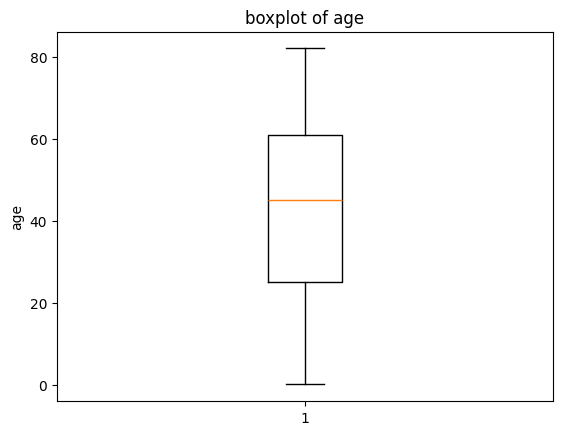

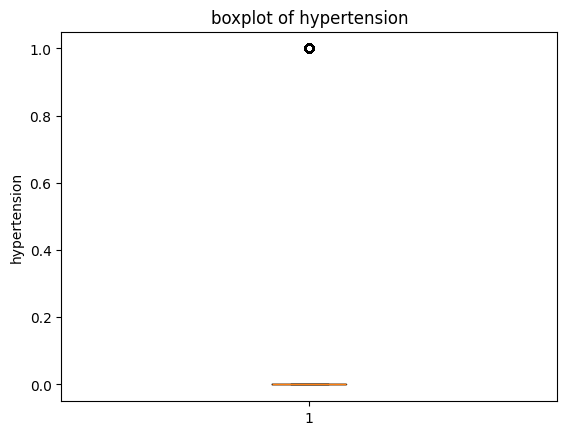

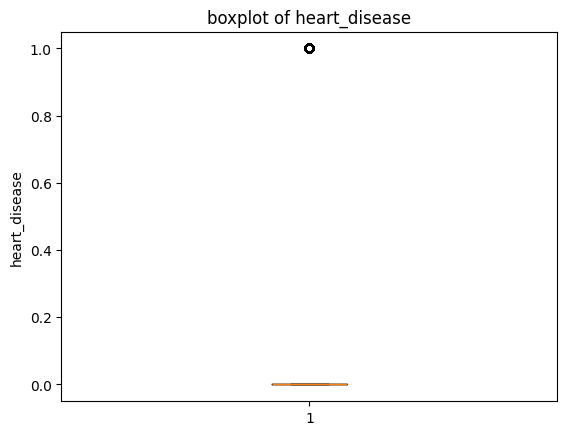

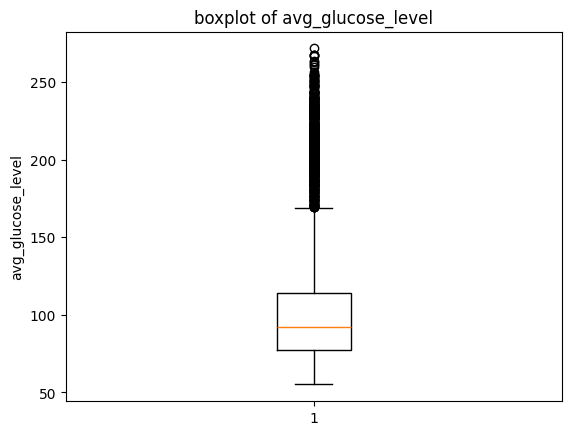

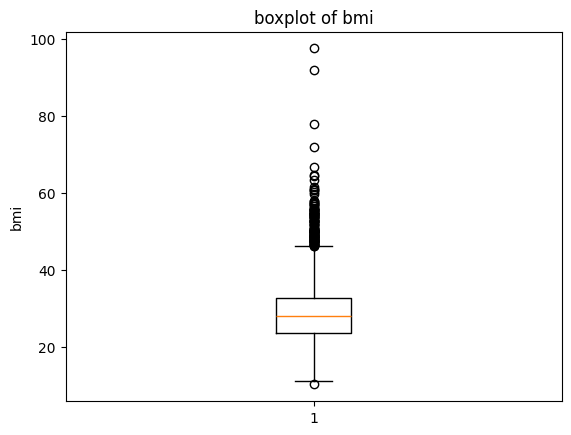

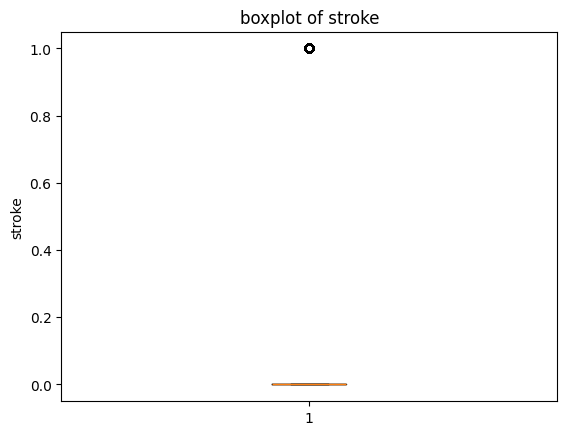

In [15]:
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        plt.boxplot(df[i])
        plt.title(f'boxplot of {i}')
        plt.ylabel(i)
        plt.show()

In [16]:
df[df['bmi'] > 50]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
113,Female,45.0,0,0,Yes,Private,Rural,224.10,56.6,never smoked,1
254,Female,47.0,0,0,Yes,Private,Urban,210.95,50.1,Unknown,0
258,Female,74.0,1,0,Yes,Self-employed,Urban,205.84,54.6,never smoked,0
270,Female,57.0,1,0,Yes,Private,Rural,129.54,60.9,smokes,0
333,Female,52.0,0,0,Yes,Private,Urban,82.24,54.7,formerly smoked,0
...,...,...,...,...,...,...,...,...,...,...,...
4650,Male,54.0,0,0,Yes,Private,Rural,100.47,50.2,formerly smoked,0
4779,Female,58.0,0,0,Yes,Self-employed,Urban,66.71,51.7,never smoked,0
4838,Female,51.0,0,0,Yes,Private,Urban,107.72,60.9,Unknown,0
4906,Female,53.0,0,0,Yes,Private,Urban,70.51,54.1,never smoked,0


In [17]:
df[df['avg_glucose_level'] > 250]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
33,Male,80.0,0,1,Yes,Self-employed,Urban,252.72,30.5,formerly smoked,1
122,Male,80.0,0,0,Yes,Private,Rural,259.63,31.7,smokes,1
135,Female,71.0,0,0,Yes,Govt_job,Urban,263.32,38.7,never smoked,1
193,Male,68.0,1,1,Yes,Private,Rural,271.74,31.1,smokes,1
220,Male,81.0,1,1,Yes,Private,Urban,250.89,28.1,smokes,1
386,Male,70.0,1,0,Yes,Self-employed,Urban,251.60,27.1,never smoked,0
755,Female,64.0,0,0,Yes,Private,Rural,250.20,27.4,Unknown,0
785,Female,69.0,0,1,Yes,Private,Rural,254.60,21.7,Unknown,0
1067,Male,67.0,1,1,Yes,Private,Rural,254.63,31.0,never smoked,0
1113,Female,66.0,0,0,Yes,Self-employed,Rural,251.46,35.2,smokes,0


In [18]:
dict1={}
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        q1=df[i].quantile(0.25)
        q3=df[i].quantile(0.75)
        iqr=q3-q1
        min_range=q1-1.5*iqr
        max_range=q3+1.5*iqr
        dict1[i]=(min_range,max_range)
        # df=df[(df[i]>=min_range) & (df[i]<=max_range) ]
dict1

{'age': (np.float64(-29.0), np.float64(115.0)),
 'hypertension': (np.float64(0.0), np.float64(0.0)),
 'heart_disease': (np.float64(0.0), np.float64(0.0)),
 'avg_glucose_level': (np.float64(21.977500000000006),
  np.float64(169.35750000000002)),
 'bmi': (np.float64(10.300000000000006), np.float64(46.29999999999999)),
 'stroke': (np.float64(0.0), np.float64(0.0))}

In [19]:
print(df[df['bmi']>=46.299]['stroke'].value_counts())

stroke
0    122
1      3
Name: count, dtype: int64


In [20]:
df=df[(df['bmi']>=dict1['bmi'][0])&(df['bmi']<=dict1['bmi'][1])]

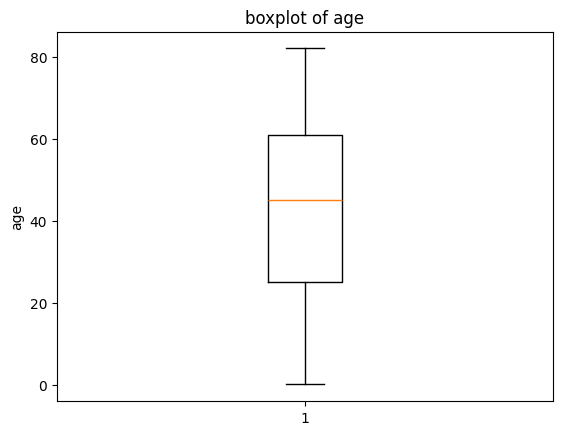

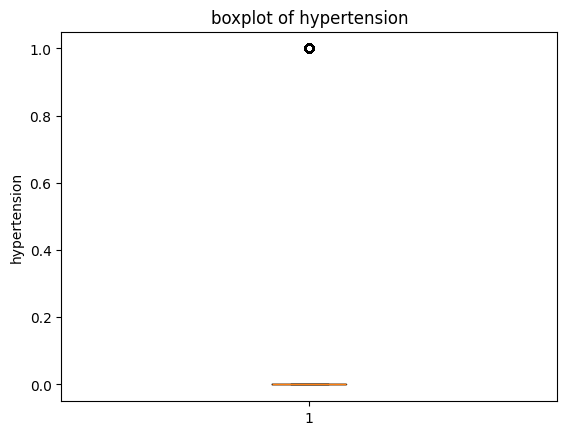

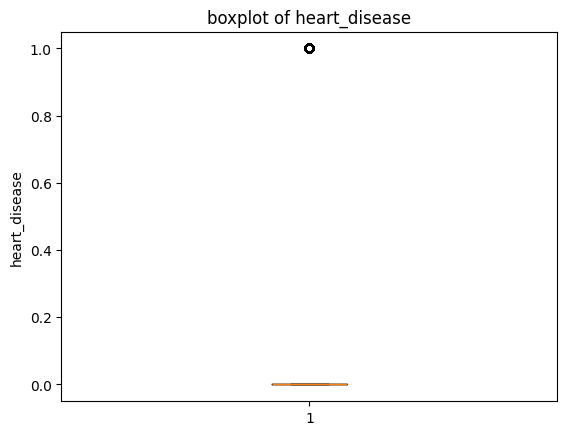

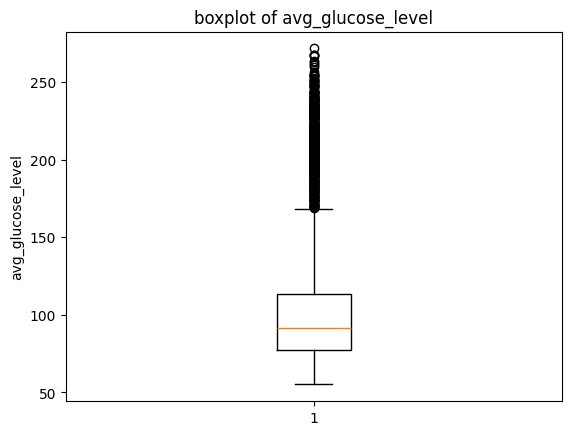

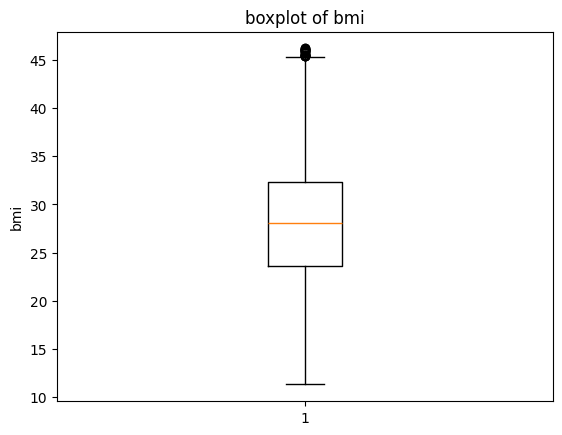

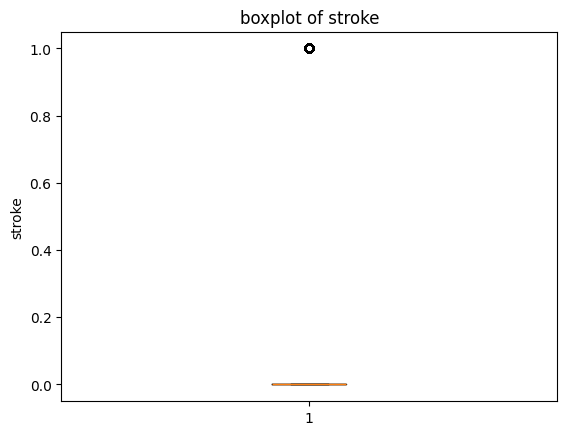

In [21]:
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        plt.boxplot(df[i])
        plt.title(f'boxplot of {i}')
        plt.ylabel(i)
        plt.show()

In [22]:
df.dtypes

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [23]:
df.dtypes

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [24]:
df=df[df['gender']!='Other']
df['gender'].value_counts()

gender
Female    2895
Male      2088
Name: count, dtype: int64

In [25]:
df['smoking_status'].value_counts()

smoking_status
never smoked       1836
Unknown            1515
formerly smoked     861
smokes              771
Name: count, dtype: int64

In [26]:
df.loc[(df['smoking_status']=='Unknown')&(df['stroke']==1),'smoking_status']='smokes'
df.loc[(df['smoking_status']=='Unknown')&(df['stroke']==0),'smoking_status']='formerly smoked'

In [27]:
df['smoking_status'].value_counts()

smoking_status
formerly smoked    2329
never smoked       1836
smokes              818
Name: count, dtype: int64

object to category converter

In [28]:
column_to_category = ['work_type', 'smoking_status']
for i in column_to_category:
    df[i] = df[i].astype('category')

Label Encoder

In [29]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder

In [30]:
label=[]
for i in df:
    if df[i].nunique()==2 and df[i].dtype=='object':
        label.append(i)
label

['gender', 'ever_married', 'Residence_type']

In [31]:
label_dict={}
for i in label:
    label_dict[i]=LabelEncoder()
    df[i]=label_dict[i].fit_transform(df[i])
label_dict

{'gender': LabelEncoder(),
 'ever_married': LabelEncoder(),
 'Residence_type': LabelEncoder()}

In [32]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1
1,0,61.0,0,0,1,Self-employed,0,202.21,28.1,never smoked,1
2,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1
3,0,49.0,0,0,1,Private,1,171.23,34.4,smokes,1
4,0,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,0,80.0,1,0,1,Private,1,83.75,28.1,never smoked,0
5106,0,81.0,0,0,1,Self-employed,1,125.20,40.0,never smoked,0
5107,0,35.0,0,0,1,Self-employed,0,82.99,30.6,never smoked,0
5108,1,51.0,0,0,1,Private,0,166.29,25.6,formerly smoked,0


one hot encoder using pandas

In [33]:
df['work_type'].unique()
df_new = df.copy()
df=pd.get_dummies(df, columns=['work_type'], drop_first=True, dtype=int)
df

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,1,67.0,0,1,1,1,228.69,36.6,formerly smoked,1,0,1,0,0
1,0,61.0,0,0,1,0,202.21,28.1,never smoked,1,0,0,1,0
2,1,80.0,0,1,1,0,105.92,32.5,never smoked,1,0,1,0,0
3,0,49.0,0,0,1,1,171.23,34.4,smokes,1,0,1,0,0
4,0,79.0,1,0,1,0,174.12,24.0,never smoked,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,0,80.0,1,0,1,1,83.75,28.1,never smoked,0,0,1,0,0
5106,0,81.0,0,0,1,1,125.20,40.0,never smoked,0,0,0,1,0
5107,0,35.0,0,0,1,0,82.99,30.6,never smoked,0,0,0,1,0
5108,1,51.0,0,0,1,0,166.29,25.6,formerly smoked,0,0,1,0,0


one hot encoder class

In [34]:
onehot=OneHotEncoder(sparse_output=False, drop='first')
res=onehot.fit_transform(df_new[['work_type']])
res

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.]], shape=(4983, 4))

In [35]:
res=pd.DataFrame(res, columns=onehot.get_feature_names_out())
res.shape

(4983, 4)

In [36]:
df_new.drop(columns=['work_type'], inplace=True)

In [37]:
df_new.reset_index(drop=True, inplace=True)
df = df_new.join(res)

In [38]:
df

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,1,67.0,0,1,1,1,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,0.0
1,0,61.0,0,0,1,0,202.21,28.1,never smoked,1,0.0,0.0,1.0,0.0
2,1,80.0,0,1,1,0,105.92,32.5,never smoked,1,0.0,1.0,0.0,0.0
3,0,49.0,0,0,1,1,171.23,34.4,smokes,1,0.0,1.0,0.0,0.0
4,0,79.0,1,0,1,0,174.12,24.0,never smoked,1,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4978,0,80.0,1,0,1,1,83.75,28.1,never smoked,0,0.0,1.0,0.0,0.0
4979,0,81.0,0,0,1,1,125.20,40.0,never smoked,0,0.0,0.0,1.0,0.0
4980,0,35.0,0,0,1,0,82.99,30.6,never smoked,0,0.0,0.0,1.0,0.0
4981,1,51.0,0,0,1,0,166.29,25.6,formerly smoked,0,0.0,1.0,0.0,0.0


ordinal encoding - smoking status

In [39]:
ordinal = OrdinalEncoder(categories=[["never smoked", "formerly smoked", "smokes"]])
df['smoking_status'] = ordinal.fit_transform(df[['smoking_status']])

Scaling

In [40]:
x=df.drop(columns=['stroke'])
y=df['stroke']

In [41]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
x_scaled = minmax.fit_transform(x)

Train test split

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=5)

Prediction model training

KNeighborsClassifier()
----------------------------
95.05016722408027
[[1421    3]
 [  71    0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1424
           1       0.00      0.00      0.00        71

    accuracy                           0.95      1495
   macro avg       0.48      0.50      0.49      1495
weighted avg       0.91      0.95      0.93      1495



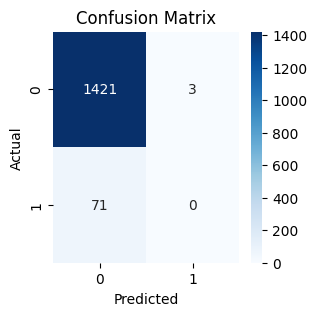


SVC()
----------------------------
95.25083612040135
[[1424    0]
 [  71    0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      1424
           1       0.00      0.00      0.00        71

    accuracy                           0.95      1495
   macro avg       0.48      0.50      0.49      1495
weighted avg       0.91      0.95      0.93      1495



c:\Users\rijok\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rijok\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rijok\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

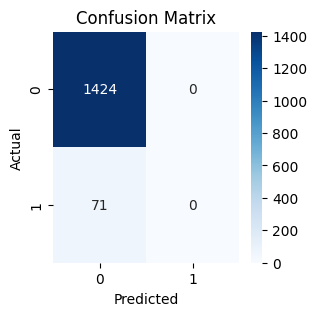


SVC(C=1000)
----------------------------
93.57859531772576
[[1394   30]
 [  66    5]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1424
           1       0.14      0.07      0.09        71

    accuracy                           0.94      1495
   macro avg       0.55      0.52      0.53      1495
weighted avg       0.92      0.94      0.93      1495



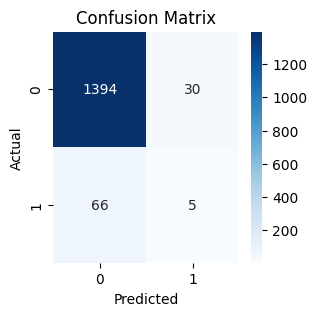

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

models=[KNeighborsClassifier(), SVC(), SVC(C=1000)]
for model in models:
    model.fit(x_train, y_train)
    y_pred=model.predict(x_test)
    print(model)
    print("----------------------------")
    print(accuracy_score(y_test, y_pred)*100)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    plt.figure(figsize=(3,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), fmt='d', cmap='Blues', annot=True)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print()

In [44]:
weighted_avg_precission = (0.95*1370+0.17*70)/1440
weighted_avg_recall = (1*1370+0.01*70)/1440
weighted_avg_f1score = (0.97*1370+0.03*70)/1440
weighted_avg_precission, weighted_avg_recall, weighted_avg_f1score

(0.9120833333333334, 0.951875, 0.9243055555555554)

In [45]:
from imblearn.under_sampling import RandomUnderSampler
under_sampler=RandomUnderSampler()
x_under, y_under = under_sampler.fit_resample(x_scaled, y)
y_under.value_counts()

stroke
0    246
1    246
Name: count, dtype: int64

In [46]:
from imblearn.over_sampling import RandomOverSampler
over_sampler=RandomOverSampler()
x_over, y_over = over_sampler.fit_resample(x_scaled, y)
pd.DataFrame(x_over).duplicated().sum()

np.int64(4491)

Smote

In [47]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_over_s, y_over_s = smote.fit_resample(x_scaled, y)

In [48]:
pd.DataFrame(x_over_s).duplicated().sum()

np.int64(0)

In [49]:
df

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,1,67.0,0,1,1,1,228.69,36.6,1.0,1,0.0,1.0,0.0,0.0
1,0,61.0,0,0,1,0,202.21,28.1,0.0,1,0.0,0.0,1.0,0.0
2,1,80.0,0,1,1,0,105.92,32.5,0.0,1,0.0,1.0,0.0,0.0
3,0,49.0,0,0,1,1,171.23,34.4,2.0,1,0.0,1.0,0.0,0.0
4,0,79.0,1,0,1,0,174.12,24.0,0.0,1,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4978,0,80.0,1,0,1,1,83.75,28.1,0.0,0,0.0,1.0,0.0,0.0
4979,0,81.0,0,0,1,1,125.20,40.0,0.0,0,0.0,0.0,1.0,0.0
4980,0,35.0,0,0,1,0,82.99,30.6,0.0,0,0.0,0.0,1.0,0.0
4981,1,51.0,0,0,1,0,166.29,25.6,1.0,0,0.0,1.0,0.0,0.0


Models in one array

In [50]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_over_s,y_over_s,test_size=0.3,random_state=5)

KNeighborsClassifier()
----------------------------
90.22159690467817
[[1197  244]
 [  34 1368]]
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      1441
           1       0.85      0.98      0.91      1402

    accuracy                           0.90      2843
   macro avg       0.91      0.90      0.90      2843
weighted avg       0.91      0.90      0.90      2843



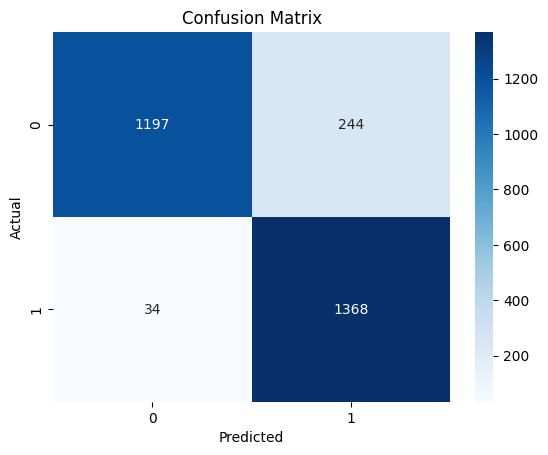


SVC()
----------------------------
84.17164966584593
[[1111  330]
 [ 120 1282]]
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1441
           1       0.80      0.91      0.85      1402

    accuracy                           0.84      2843
   macro avg       0.85      0.84      0.84      2843
weighted avg       0.85      0.84      0.84      2843



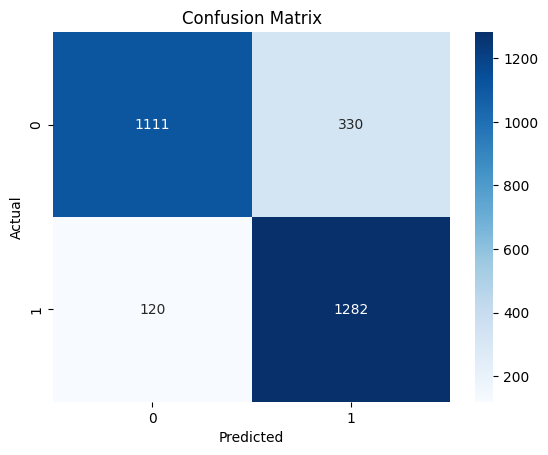


SVC(C=1000)
----------------------------
90.96025325360534
[[1235  206]
 [  51 1351]]
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      1441
           1       0.87      0.96      0.91      1402

    accuracy                           0.91      2843
   macro avg       0.91      0.91      0.91      2843
weighted avg       0.91      0.91      0.91      2843



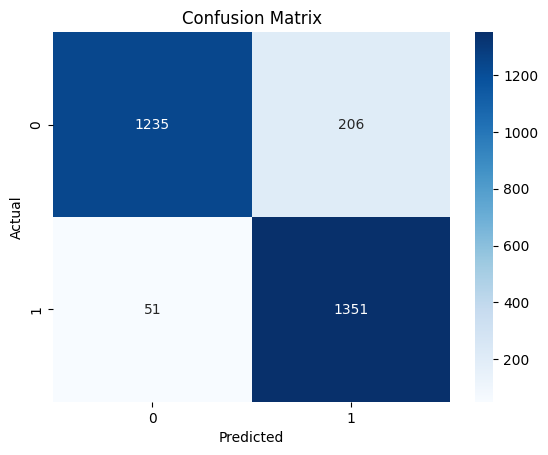

In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

models=[KNeighborsClassifier(), SVC(), SVC(C=1000)]
for model in models:
    model.fit(x_train, y_train)
    y_pred=model.predict(x_test)
    print(model)
    print("----------------------------")
    print(accuracy_score(y_test, y_pred)*100)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), fmt='d', cmap='Blues', annot=True)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print()